In [ ]:
## importing libraries
import torch 
import torch.nn as nn
import torchvision 
from torch.utils.data import Dataset,DataLoader
from torch.nn import functional as F
import numpy as np 
from torch.utils import tensorboard 

In [ ]:
class Discriminator(nn.Module):
    def __init__(self,channels_img,features_d):
        super().__init__()
        self.disc = nn.Sequential(
            # input : N X channels_mg X 64 X 64
            nn.Conv2d(channels_img,features_d,kernel_size=4,stride=2,padding=1), # 32X32
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 4, 2, 1), # 16X16
            self._block(features_d * 2, features_d * 4, 4, 2, 1), # 8x8
            self._block(features_d * 4, features_d * 8, 4, 2, 1), # 4x4
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=2, padding=0),
            nn.Sigmoid(), # final one value 
        )
        
    def _block(self,in_channels,out_channels,kernel_size,stride,padding):
        return nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias = False # 
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )
    def forward(self,x):
        return self.disc(x)
        

In [ ]:
class Generator(nn.Module):
    def __init__(self,channel_noise,channel_img,features_g):
        super().__init__()
        self.gen = nn.Sequential(
            # input : N X channel_noise X 1 X 1
            self._block(channel_noise, features_g * 16, 4, 1, 0),  # img: 4x4
            self._block(features_g * 16, features_g * 8, 4, 2, 1),  # img: 8x8
            self._block(features_g * 8, features_g * 4, 4, 2, 1),  # img: 16x16
            self._block(features_g * 4, features_g * 2, 4, 2, 1),  # img: 32x32
            nn.ConvTranspose2d(features_g*2,channel_img,kernel_size=4,stride=2,padding=1),
            nn.Tanh()
        )

    def _block(self,in_channels,out_channels,kernel_size,stride,padding):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias = False # 
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )

    def forward(self,x):
        x = self.gen(x)
        # print(x.shape)
        return x
        

In [ ]:
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal(m.weight.data,0.0,0.02)
            

In [ ]:
def test():
    N, in_channels, H, W = 8, 3, 64, 64
    noise_dim = 100
    x = torch.randn((N, in_channels, H, W))
    print(x.shape)
    disc = Discriminator(in_channels, 8)
    assert disc(x).shape == (N, 1, 1, 1), "Discriminator test failed"
    gen = Generator(noise_dim, in_channels, 8)
    z = torch.randn((N, noise_dim, 1, 1))
    print(z.shape)
    assert gen(z).shape == (N, in_channels, H, W), "Generator test failed"
    print("Success, tests passed!")

test()

In [ ]:
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter
import torch.optim as optim

In [ ]:
# Hyperparameters etc.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LEARNING_RATE = 2e-4  # could also use two lrs, one for gen and one for disc
BATCH_SIZE = 128
IMAGE_SIZE = 64
CHANNELS_IMG = 3
NOISE_DIM = 100
NUM_EPOCHS = 5
FEATURES_DISC = 64
FEATURES_GEN = 64

In [ ]:
transforms = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # Pass a tuple (64, 64)
        transforms.ToTensor(),
        transforms.Normalize(
            [0.5 for _ in range(CHANNELS_IMG)],
            [0.5 for _ in range(CHANNELS_IMG)],
        ),
    ]
)

# If you train on MNIST, remember to set channels_img to 1
dataset = datasets.ImageFolder(root="/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba", transform=transforms)

In [ ]:
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
gen = Generator(NOISE_DIM, CHANNELS_IMG, FEATURES_GEN).to(device)
disc = Discriminator(CHANNELS_IMG, FEATURES_DISC).to(device)
initialize_weights(gen)
initialize_weights(disc)

opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
criterion = nn.BCELoss()

fixed_noise = torch.randn(32, NOISE_DIM, 1, 1).to(device)
writer_real = SummaryWriter(f"logs/real")
writer_fake = SummaryWriter(f"logs/fake")
step = 0

gen.train()
disc.train()

In [ ]:
for epoch in range(NUM_EPOCHS):
    for batch_idx,(real,_) in enumerate(dataloader):
        real = real.to(device)
        noise = torch.randn(BATCH_SIZE,NOISE_DIM,1,1).to(device)
        fake = gen(noise) # fake sample

        ### Train Discriminator: max log(D(x)) + log(1 - D(G(z)))
        disc.zero_grad()
        disc_real = disc(real).reshape(-1) # 1/0
        loss_disc_real = criterion(disc_real,torch.ones_like(disc_real))
        disc_fake = disc(fake.detach()).reshape(-1)
        loss_disc_fake = criterion(disc_fake,torch.zeros_like(disc_fake))
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        loss_disc.backward()
        opt_disc.step()

        ### Train Generator: min log(1 - D(G(z))) <-> max log(D(G(z))
        gen.zero_grad()
        output = disc(fake).reshape(-1)
        loss_gen = criterion(output,torch.ones_like(output)) # we try to fool
        loss_gen.backward()
        opt_gen.step()

        ## print ocassinaly on dashboard 
        if batch_idx % 100 == 0:
            print(
                f"Epoch [{epoch}/{NUM_EPOCHS}] Batch {batch_idx}/{len(dataloader)} \
                  Loss D: {loss_disc:.4f}, loss G: {loss_gen:.4f}"
            )

            with torch.no_grad():
                fake = gen(fixed_noise)
                # take out (up to) 32 examples
                img_grid_real = torchvision.utils.make_grid(real[:32], normalize=True)
                img_grid_fake = torchvision.utils.make_grid(fake[:32], normalize=True)

                writer_real.add_image("Real", img_grid_real, global_step=step)
                writer_fake.add_image("Fake", img_grid_fake, global_step=step)
            step += 1 
    torch.save(gen.state_dict(), "generator.pth")
    torch.save(disc.state_dict(), "discriminator.pth")

In [ ]:
import matplotlib.pyplot as plt 

N, in_channels, H, W = 8, 3, 64, 64  # Note: Set in_channels=1 for MNIST
noise_dim = 100

gen = Generator(noise_dim, in_channels, FEATURES_GEN).to(device)
gen.load_state_dict(torch.load("generator.pth", map_location=device))
gen.eval()

In [ ]:
gen.eval()
with torch.no_grad():
    # 1. Run test loop assertions
    for i in range(10):
        z = torch.randn((N, noise_dim, 1, 1)).to(device)
        fake_images = gen(z)
        assert fake_images.shape == (N, in_channels, H, W), "Generator Failed"
    fake_images = fake_images.detach().cpu()
    img_grid = torchvision.utils.make_grid(fake_images, nrow=8, normalize=True)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(img_grid.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.title("Generated Images from Loaded Weights")
    plt.show()

print("All generator assertions passed successfully!")

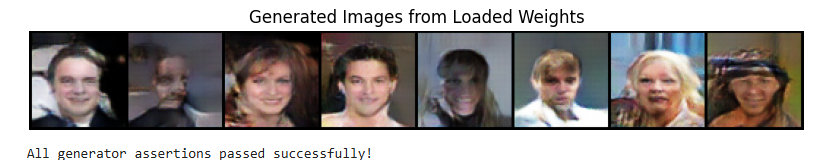

In [ ]:
from IPython.display import FileLink, display

# Direct clickable links in the notebook output
display(FileLink(r'generator.pth'))
display(FileLink(r'discriminator.pth'))